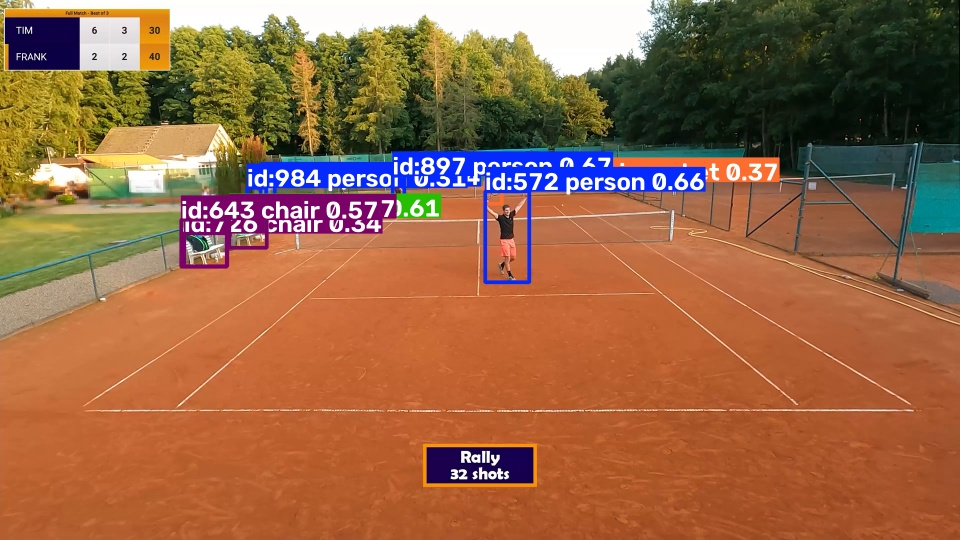

In [7]:
import cv2
from IPython.display import Image, display
from ultralytics import YOLO

model = YOLO("yolo11n.pt")
cap = cv2.VideoCapture("../data/yt_amateur_tennis.mp4")

# 1. Initialize an empty display handle
handle = display(display_id=True)

try:
    while cap.isOpened():
        success, frame = cap.read()
        if not success:
            break

        results = model.track(
            frame, 
            persist=True,
            tracker="bytetrack.yaml",
            imgsz=1280,
            conf=0.30, 
            verbose=False
        )
        annotated_frame = results[0].plot()

        # Resize to maintain high frame rates in notebook DOM
        h, w = annotated_frame.shape[:2]
        small_frame = cv2.resize(annotated_frame, (int(w * 0.5), int(h * 0.5)))

        # Compress to JPEG
        _, buffer = cv2.imencode(".jpg", small_frame)

        # Update the existing DOM element directly (zero flicker)
        handle.update(Image(data=buffer.tobytes()))
finally:
    cap.release()